In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format","{:.4f}".format)
sns.set_style("whitegrid")



In [4]:
cols = ['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
        'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
        'loan_status', 'purpose', 'dti', 'open_acc', 'pub_rec',
        'revol_bal', 'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies']

df_accepted = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/Datasets/Leanding Club/accepted_2007_to_2018Q4.csv.gz",
    usecols=cols,
    nrows=500000,
    low_memory=False
)

In [5]:
df_accepted.sample(1)

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,loan_status,purpose,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies
407289,28000.0000,60 months,15.9900,680.7600,D,D2,9 years,MORTGAGE,80000.0000,Source Verified,Current,debt_consolidation,28.3200,5.0000,0.0000,7185.0000,102.6000,30.0000,0.0000,0.0000


In [6]:
df_accepted.describe()


,loan_amnt,int_rate,installment,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies
count,499998.0000,499998.0000,499998.0000,499998.0000,499782.0000,499998.0000,499998.0000,499998.0000,499733.0000,499998.0000,499998.0000,499998.0000
mean,15388.9606,12.5742,446.3888,77186.3204,19.2454,11.8611,0.2228,17430.6543,52.2018,25.0398,1.6396,0.1316
std,8852.2712,4.4382,252.5690,75346.6371,12.0556,5.6803,0.6309,23881.8930,24.3927,12.1386,1.9578,0.3783
min,1000.0000,5.3100,14.0100,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2.0000,0.0000,0.0000
25%,8500.0000,9.1700,262.7500,46000.0000,12.3900,8.0000,0.0000,6274.0000,33.9000,16.0000,0.0000,0.0000
50%,14000.0000,12.2900,385.9100,65000.0000,18.4700,11.0000,0.0000,11790.0000,52.4000,23.0000,1.0000,0.0000
75%,20000.0000,15.5900,589.2200,92000.0000,25.3100,15.0000,0.0000,21136.0000,71.0000,32.0000,3.0000,0.0000
max,40000.0000,30.9900,1607.8000,9500000.0000,999.0000,90.0000,86.0000,2904836.0000,193.0000,169.0000,52.0000,11.0000


In [7]:
cols=df_accepted.dtypes.sort_values().index.tolist()

In [8]:
df=df_accepted[cols]
df.head()

,loan_amnt,total_acc,revol_util,revol_bal,pub_rec,open_acc,dti,mort_acc,pub_rec_bankruptcies,installment,int_rate,annual_inc,home_ownership,loan_status,purpose,emp_length,sub_grade,grade,term,verification_status
0,3600.0000,13.0000,29.7000,2765.0000,0.0000,7.0000,5.9100,1.0000,0.0000,123.0300,13.9900,55000.0000,MORTGAGE,Fully Paid,debt_consolidation,10+ years,C4,C,36 months,Not Verified
1,24700.0000,38.0000,19.2000,21470.0000,0.0000,22.0000,16.0600,4.0000,0.0000,820.2800,11.9900,65000.0000,MORTGAGE,Fully Paid,small_business,10+ years,C1,C,36 months,Not Verified
2,20000.0000,18.0000,56.2000,7869.0000,0.0000,6.0000,10.7800,5.0000,0.0000,432.6600,10.7800,63000.0000,MORTGAGE,Fully Paid,home_improvement,10+ years,B4,B,60 months,Not Verified
3,35000.0000,17.0000,11.6000,7802.0000,0.0000,13.0000,17.0600,1.0000,0.0000,829.9000,14.8500,110000.0000,MORTGAGE,Current,debt_consolidation,10+ years,C5,C,60 months,Source Verified
4,10400.0000,35.0000,64.5000,21929.0000,0.0000,12.0000,25.3700,6.0000,0.0000,289.9100,22.4500,104433.0000,MORTGAGE,Fully Paid,major_purchase,3 years,F1,F,60 months,Source Verified


In [9]:
posibles_columnas_enteras=["loan_amnt","total_acc","revol_bal","pub_rec","open_acc","mort_acc","pub_rec_bankruptcies"]
df[posibles_columnas_enteras].describe()

,loan_amnt,total_acc,revol_bal,pub_rec,open_acc,mort_acc,pub_rec_bankruptcies
count,499998.0000,499998.0000,499998.0000,499998.0000,499998.0000,499998.0000,499998.0000
mean,15388.9606,25.0398,17430.6543,0.2228,11.8611,1.6396,0.1316
std,8852.2712,12.1386,23881.8930,0.6309,5.6803,1.9578,0.3783
min,1000.0000,2.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,8500.0000,16.0000,6274.0000,0.0000,8.0000,0.0000,0.0000
50%,14000.0000,23.0000,11790.0000,0.0000,11.0000,1.0000,0.0000
75%,20000.0000,32.0000,21136.0000,0.0000,15.0000,3.0000,0.0000
max,40000.0000,169.0000,2904836.0000,86.0000,90.0000,52.0000,11.0000


In [10]:
for col in posibles_columnas_enteras:
  have_decimals=(df[col].dropna() % 1 !=0).any()
  have_nan=(df[col].isna().any())
  print(f"La columna {col} Tiene decimales? :{have_decimals}")
  print(f"La columna {col} Tiene Nan? :{have_nan}")
  print(f"_________________")

La columna loan_amnt Tiene decimales? :False
La columna loan_amnt Tiene Nan? :True
_________________
La columna total_acc Tiene decimales? :False
La columna total_acc Tiene Nan? :True
_________________
La columna revol_bal Tiene decimales? :False
La columna revol_bal Tiene Nan? :True
_________________
La columna pub_rec Tiene decimales? :False
La columna pub_rec Tiene Nan? :True
_________________
La columna open_acc Tiene decimales? :False
La columna open_acc Tiene Nan? :True
_________________
La columna mort_acc Tiene decimales? :False
La columna mort_acc Tiene Nan? :True
_________________
La columna pub_rec_bankruptcies Tiene decimales? :False
La columna pub_rec_bankruptcies Tiene Nan? :True
_________________


Como tiene valores nan se procedera a eliminar los nan mas adelante para luego pasarlos a Int64 o Int32 o Int8 dependiendo de lo que requiera

## Trabajando con variables categoricas

In [11]:
cols_object=df.dtypes[df.dtypes==object].index.tolist()
cols_object

['home_ownership',
 'loan_status',
 'purpose',
 'emp_length',
 'sub_grade',
 'grade',
 'term',
 'verification_status']

## Columna verification status

In [12]:
df["verification_status"].value_counts()

,count
verification_status,
Source Verified,215223
Not Verified,143182
Verified,141593


Como es una variable categorica mas adelante le aplicare get_dummies

## Columna Term

In [13]:
df["term"]=df["term"].str.strip().str.replace(" months", "").astype("float64")

## Columna grade

In [14]:
df["grade"].value_counts()

,count
grade,
C,141680
B,141336
A,92870
D,73872
E,37663
F,10317
G,2260


De igual forma es categorica por lo que aplicare get dummies mas adelante

##Columna Sub_grade

In [15]:
same_grade = (df["grade"].dropna()!=df["sub_grade"].dropna().str[0]).any()
print(f"Todas la columnas de grade y subgrade matchean el grado? -> {not same_grade}")

Todas la columnas de grade y subgrade matchean el grado? -> True


In [16]:
df["sub_grade"].value_counts().sort_index()

,count
sub_grade,
A1,15765
A2,15216
A3,14969
A4,20010
A5,26910
B1,27153
B2,27074
B3,28753
B4,29682


Como se logra apreciar esta columna tiene ya a la columan grade por lo que se procedera a hacer es eliminar la columna grade pero ademas como son grades cada categoria tiene cierto nivel, por lo que podriamos cambiarlo de tipo a ordinal

In [17]:
sorted_grades=sorted(df["sub_grade"].dropna().unique())
print(sorted_grades)

['A1', 'A2', 'A3', 'A4', 'A5', 'B1', 'B2', 'B3', 'B4', 'B5', 'C1', 'C2', 'C3', 'C4', 'C5', 'D1', 'D2', 'D3', 'D4', 'D5', 'E1', 'E2', 'E3', 'E4', 'E5', 'F1', 'F2', 'F3', 'F4', 'F5', 'G1', 'G2', 'G3', 'G4', 'G5']


In [18]:
grade_dict= { grade : i+1 for i,grade in enumerate(sorted_grades)}
grade_dict

{'A1': 1,
 'A2': 2,
 'A3': 3,
 'A4': 4,
 'A5': 5,
 'B1': 6,
 'B2': 7,
 'B3': 8,
 'B4': 9,
 'B5': 10,
 'C1': 11,
 'C2': 12,
 'C3': 13,
 'C4': 14,
 'C5': 15,
 'D1': 16,
 'D2': 17,
 'D3': 18,
 'D4': 19,
 'D5': 20,
 'E1': 21,
 'E2': 22,
 'E3': 23,
 'E4': 24,
 'E5': 25,
 'F1': 26,
 'F2': 27,
 'F3': 28,
 'F4': 29,
 'F5': 30,
 'G1': 31,
 'G2': 32,
 'G3': 33,
 'G4': 34,
 'G5': 35}

In [19]:
df["sub_grade_num"]=df["sub_grade"].map(grade_dict)
df=df.drop(["grade","sub_grade"], axis=1)
df.sample(20)

,loan_amnt,total_acc,revol_util,revol_bal,pub_rec,open_acc,dti,mort_acc,pub_rec_bankruptcies,installment,int_rate,annual_inc,home_ownership,loan_status,purpose,emp_length,term,verification_status,sub_grade_num
333434,10000.0000,25.0000,70.5000,17545.0000,0.0000,10.0000,14.2000,2.0000,0.0000,258.5300,18.8400,110000.0000,MORTGAGE,Charged Off,debt_consolidation,10+ years,60.0000,Not Verified,22.0000
498585,8000.0000,25.0000,40.0000,11587.0000,1.0000,9.0000,29.0600,0.0000,0.0000,256.0400,9.4400,70000.0000,RENT,Fully Paid,credit_card,4 years,36.0000,Not Verified,6.0000
195880,17625.0000,11.0000,78.2000,14077.0000,0.0000,9.0000,12.8000,3.0000,0.0000,635.9500,17.8600,42000.0000,MORTGAGE,Charged Off,debt_consolidation,5 years,36.0000,Verified,20.0000
485289,16000.0000,12.0000,55.2000,16897.0000,0.0000,7.0000,17.4100,0.0000,0.0000,512.0800,9.4400,26000.0000,OWN,Current,debt_consolidation,NaN,36.0000,Verified,6.0000
389563,20550.0000,38.0000,32.8000,23716.0000,0.0000,17.0000,33.2900,5.0000,0.0000,520.2800,17.8600,50000.0000,MORTGAGE,Fully Paid,debt_consolidation,10+ years,60.0000,Source Verified,20.0000
94445,7000.0000,7.0000,59.5000,19348.0000,0.0000,6.0000,9.3300,0.0000,0.0000,219.0000,7.8900,40000.0000,RENT,Fully Paid,major_purchase,2 years,36.0000,Source Verified,5.0000
19936,16000.0000,34.0000,24.5000,22355.0000,0.0000,24.0000,12.5700,2.0000,0.0000,493.2300,6.8900,56000.0000,MORTGAGE,Fully Paid,debt_consolidation,1 year,36.0000,Not Verified,3.0000
421042,8750.0000,17.0000,69.0000,10490.0000,0.0000,5.0000,27.7000,0.0000,0.0000,292.2600,12.3900,25000.0000,MORTGAGE,Fully Paid,credit_card,2 years,36.0000,Not Verified,11.0000
344864,17000.0000,21.0000,92.7000,7137.0000,1.0000,10.0000,14.3100,0.0000,0.0000,494.0100,24.5000,51500.0000,RENT,Current,debt_consolidation,< 1 year,60.0000,Source Verified,28.0000
245499,18000.0000,17.0000,73.3000,9596.0000,0.0000,10.0000,19.4800,0.0000,0.0000,573.8300,9.1700,67460.0000,RENT,Fully Paid,debt_consolidation,10+ years,36.0000,Not Verified,7.0000


##Columna emp_length

In [20]:
df['emp_length'].value_counts().sort_index()

,count
emp_length,
1 year,32720
10+ years,167573
2 years,44991
3 years,40068
4 years,29522
5 years,29892
6 years,20310
7 years,21363
8 years,23968


In [21]:
df["emp_length"]=df["emp_length"].str.replace("< 1 year","0")
df["emp_length"]=df["emp_length"].str.replace("10+ years","10")


In [22]:
df["emp_length"].value_counts().sort_index()

,count
emp_length,
0,39655
1 year,32720
10,167573
2 years,44991
3 years,40068
4 years,29522
5 years,29892
6 years,20310
7 years,21363


In [23]:
df["emp_length"]=df["emp_length"].str.extract("(\d+)").astype(float)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1112/2413553460.py:1: SyntaxWarning: invalid escape sequence '\d'
  df["emp_length"]=df["emp_length"].str.extract("(\d+)").astype(float)


In [24]:
df["emp_length"].value_counts().sort_index()

,count
emp_length,
0.0000,39655
1.0000,32720
2.0000,44991
3.0000,40068
4.0000,29522
5.0000,29892
6.0000,20310
7.0000,21363
8.0000,23968


Antes de continuar vamos a Trabajar primero con el target que es loan_status

In [25]:
df["loan_status"].value_counts()

,count
loan_status,
Fully Paid,312340
Current,104240
Charged Off,78824
Late (31-120 days),2977
In Grace Period,1046
Late (16-30 days),567
Default,4


In [26]:
df=df[df["loan_status"].isin(["Fully Paid","Charged Off"])]

In [27]:
df["loan_status"]=df["loan_status"].map({"Fully Paid":0,"Charged Off":1})
df["loan_status"].value_counts()

,count
loan_status,
0,312340
1,78824


In [28]:
df.sample(10)

,loan_amnt,total_acc,revol_util,revol_bal,pub_rec,open_acc,dti,mort_acc,pub_rec_bankruptcies,installment,int_rate,annual_inc,home_ownership,loan_status,purpose,emp_length,term,verification_status,sub_grade_num
107128,5000.0000,51.0000,14.9000,5477.0000,0.0000,20.0000,12.9200,7.0000,0.0000,154.9900,7.2600,118000.0000,MORTGAGE,0,debt_consolidation,10.0000,36.0000,Not Verified,4.0000
8057,5200.0000,12.0000,49.4000,9436.0000,0.0000,10.0000,14.1800,0.0000,0.0000,170.7900,11.2200,27000.0000,RENT,0,debt_consolidation,1.0000,36.0000,Verified,10.0000
469709,32000.0000,30.0000,44.4000,21476.0000,0.0000,5.0000,4.6600,5.0000,0.0000,993.2000,7.3500,142000.0000,MORTGAGE,0,debt_consolidation,10.0000,36.0000,Verified,4.0000
73077,6000.0000,13.0000,31.6000,3098.0000,1.0000,7.0000,2.7700,1.0000,0.0000,200.9900,12.5900,65000.0000,RENT,0,small_business,1.0000,36.0000,Source Verified,12.0000
414492,10000.0000,14.0000,66.7000,12476.0000,0.0000,9.0000,19.2000,0.0000,0.0000,329.4800,11.4400,66000.0000,RENT,0,debt_consolidation,4.0000,36.0000,Not Verified,9.0000
173110,10000.0000,11.0000,50.1000,4510.0000,0.0000,6.0000,7.2800,0.0000,0.0000,223.9200,12.2900,75000.0000,MORTGAGE,0,debt_consolidation,2.0000,60.0000,Not Verified,11.0000
10411,20000.0000,22.0000,45.0000,12552.0000,0.0000,17.0000,36.3600,0.0000,0.0000,656.8600,11.2200,54000.0000,RENT,0,debt_consolidation,2.0000,36.0000,Verified,10.0000
311890,19600.0000,31.0000,70.5000,36366.0000,0.0000,13.0000,24.4800,2.0000,0.0000,657.4800,12.6900,48000.0000,MORTGAGE,0,credit_card,3.0000,36.0000,Not Verified,12.0000
175191,9600.0000,9.0000,92.0000,8001.0000,0.0000,5.0000,6.7500,3.0000,0.0000,322.0400,12.6900,51586.0000,MORTGAGE,0,debt_consolidation,2.0000,36.0000,Verified,12.0000
417666,16000.0000,61.0000,79.5000,36350.0000,0.0000,28.0000,18.5600,7.0000,0.0000,393.2700,16.4900,280000.0000,MORTGAGE,0,debt_consolidation,6.0000,60.0000,Verified,18.0000


## Columna purpose

In [29]:
categorias_purpose=df["purpose"].unique().tolist()
print(categorias_purpose)

['debt_consolidation', 'small_business', 'home_improvement', 'major_purchase', 'credit_card', 'other', 'house', 'vacation', 'car', 'medical', 'moving', 'renewable_energy', 'wedding', 'educational']


In [30]:
min_cant=500 #definimos un minimo para no llenarnos de categorias
for cat in categorias_purpose:
  if(df["purpose"].value_counts()[cat] < min_cant):
    df["purpose"]=df["purpose"].str.replace(cat,"other")
print(df["purpose"].value_counts())

purpose
debt_consolidation    230090
credit_card            93081
home_improvement       23964
other                  19768
major_purchase          7248
medical                 3976
car                     3413
small_business          3266
moving                  2437
vacation                2320
house                   1601
Name: count, dtype: int64


In [31]:
df["purpose"].value_counts()

,count
purpose,
debt_consolidation,230090
credit_card,93081
home_improvement,23964
other,19768
major_purchase,7248
medical,3976
car,3413
small_business,3266
moving,2437


ahora que movi las categorias con menos valores y las puse en other, mas adelante hare get_dummies

In [32]:
df.sample(10)

,loan_amnt,total_acc,revol_util,revol_bal,pub_rec,open_acc,dti,mort_acc,pub_rec_bankruptcies,installment,int_rate,annual_inc,home_ownership,loan_status,purpose,emp_length,term,verification_status,sub_grade_num
15588,30000.0000,6.0000,68.0000,34731.0000,0.0000,6.0000,5.7700,0.0000,0.0000,845.5500,22.9900,185000.0000,RENT,1,debt_consolidation,5.0000,60.0000,Verified,27.0000
264832,20000.0000,17.0000,70.8000,24555.0000,0.0000,9.0000,10.7600,1.0000,0.0000,616.5400,6.8900,100000.0000,MORTGAGE,0,credit_card,3.0000,36.0000,Source Verified,3.0000
355918,20800.0000,15.0000,44.2000,4599.0000,1.0000,8.0000,38.7100,0.0000,1.0000,750.5100,17.8600,43258.0000,RENT,0,other,8.0000,36.0000,Verified,20.0000
319360,18400.0000,17.0000,86.6000,14022.0000,0.0000,7.0000,11.7100,4.0000,0.0000,443.6500,15.6100,85000.0000,MORTGAGE,0,debt_consolidation,10.0000,60.0000,Source Verified,16.0000
368122,24350.0000,33.0000,55.3000,20302.0000,1.0000,21.0000,22.7100,4.0000,0.0000,862.7100,16.5500,67000.0000,MORTGAGE,1,debt_consolidation,10.0000,36.0000,Source Verified,17.0000
298434,24800.0000,16.0000,33.7000,13318.0000,0.0000,9.0000,9.8500,0.0000,0.0000,907.0700,18.8400,120000.0000,RENT,0,other,4.0000,36.0000,Source Verified,22.0000
164611,9000.0000,24.0000,52.0000,18225.0000,0.0000,8.0000,21.1900,0.0000,0.0000,286.9200,9.1700,35000.0000,OWN,0,credit_card,7.0000,36.0000,Not Verified,7.0000
400886,20000.0000,46.0000,63.9000,60172.0000,0.0000,16.0000,16.3100,5.0000,0.0000,612.8900,6.4900,143000.0000,MORTGAGE,0,debt_consolidation,10.0000,36.0000,Verified,2.0000
270015,12000.0000,10.0000,28.9000,7678.0000,0.0000,8.0000,13.0900,0.0000,0.0000,375.4300,7.8900,65000.0000,RENT,0,credit_card,7.0000,36.0000,Not Verified,5.0000
204235,6000.0000,20.0000,92.1000,22926.0000,0.0000,9.0000,16.8600,3.0000,0.0000,187.7200,7.8900,103000.0000,MORTGAGE,0,debt_consolidation,3.0000,36.0000,Source Verified,5.0000


## Columna home_ownership

In [33]:
df['home_ownership'].value_counts()

,count
home_ownership,
MORTGAGE,189879
RENT,158126
OWN,43156
ANY,3


In [34]:
df=df[df["home_ownership"]!="ANY"]

In [35]:
df['home_ownership'].value_counts()

,count
home_ownership,
MORTGAGE,189879
RENT,158126
OWN,43156


In [36]:
df.sample(10)

,loan_amnt,total_acc,revol_util,revol_bal,pub_rec,open_acc,dti,mort_acc,pub_rec_bankruptcies,installment,int_rate,annual_inc,home_ownership,loan_status,purpose,emp_length,term,verification_status,sub_grade_num
96039,16000.0000,8.0000,77.3000,12215.0000,0.0000,6.0000,34.0500,0.0000,0.0000,533.6500,12.2900,62000.0000,OWN,0,credit_card,NaN,36.0000,Verified,11.0000
396032,4000.0000,17.0000,35.5000,2061.0000,0.0000,8.0000,36.0300,0.0000,0.0000,141.6000,16.4900,45000.0000,RENT,0,moving,2.0000,36.0000,Not Verified,18.0000
8198,4800.0000,11.0000,70.3000,4921.0000,0.0000,8.0000,14.9000,0.0000,0.0000,170.0700,16.5500,50000.0000,RENT,0,credit_card,3.0000,36.0000,Source Verified,17.0000
103533,20000.0000,33.0000,71.3000,8195.0000,0.0000,8.0000,14.6900,3.0000,0.0000,447.8300,12.2900,50000.0000,MORTGAGE,0,debt_consolidation,3.0000,60.0000,Not Verified,11.0000
420620,3000.0000,27.0000,48.5000,30584.0000,0.0000,17.0000,16.9100,4.0000,0.0000,99.6300,11.9900,80000.0000,MORTGAGE,0,other,10.0000,36.0000,Not Verified,10.0000
100843,20000.0000,15.0000,47.1000,21499.0000,1.0000,6.0000,7.8300,1.0000,0.0000,447.8300,12.2900,55000.0000,RENT,1,debt_consolidation,0.0000,60.0000,Not Verified,11.0000
207760,9700.0000,15.0000,59.2000,8993.0000,0.0000,9.0000,14.0100,0.0000,0.0000,339.1600,15.6100,25534.4800,RENT,1,credit_card,5.0000,36.0000,Source Verified,16.0000
327962,10000.0000,13.0000,45.2000,21061.0000,0.0000,11.0000,10.3900,0.0000,0.0000,307.3100,6.6800,40000.0000,RENT,0,credit_card,0.0000,36.0000,Not Verified,3.0000
223104,11250.0000,21.0000,10.8000,893.0000,1.0000,6.0000,1.1400,2.0000,1.0000,257.8800,13.3300,42000.0000,MORTGAGE,0,debt_consolidation,10.0000,60.0000,Not Verified,13.0000
307627,7200.0000,33.0000,87.0000,10173.0000,1.0000,11.0000,27.1500,4.0000,1.0000,248.3600,14.6500,88000.0000,MORTGAGE,0,debt_consolidation,10.0000,36.0000,Not Verified,15.0000


luego procederemos a hacer get_dummies

In [37]:
df.dtypes

,0
loan_amnt,float64
total_acc,float64
revol_util,float64
revol_bal,float64
pub_rec,float64
open_acc,float64
dti,float64
mort_acc,float64
pub_rec_bankruptcies,float64
installment,float64


## Eliminar Nans

In [38]:
df.sample(10)

,loan_amnt,total_acc,revol_util,revol_bal,pub_rec,open_acc,dti,mort_acc,pub_rec_bankruptcies,installment,int_rate,annual_inc,home_ownership,loan_status,purpose,emp_length,term,verification_status,sub_grade_num
187552,7000.0000,50.0000,1.2000,494.0000,1.0000,16.0000,1.3700,2.0000,1.0000,215.7900,6.8900,50000.0000,OWN,1,debt_consolidation,10.0000,36.0000,Verified,3.0000
146596,8400.0000,25.0000,76.8000,14135.0000,0.0000,9.0000,30.8100,2.0000,0.0000,260.3700,7.2600,52653.0000,MORTGAGE,0,debt_consolidation,10.0000,36.0000,Source Verified,4.0000
159232,5000.0000,21.0000,37.6000,10595.0000,0.0000,15.0000,16.7100,4.0000,0.0000,166.7700,12.2900,54000.0000,MORTGAGE,0,credit_card,10.0000,36.0000,Not Verified,11.0000
159242,8000.0000,23.0000,37.1000,7707.0000,0.0000,9.0000,10.9600,0.0000,0.0000,270.8300,13.3300,225000.0000,RENT,0,debt_consolidation,10.0000,36.0000,Source Verified,13.0000
341741,3325.0000,20.0000,75.9000,4934.0000,0.0000,7.0000,16.6500,2.0000,0.0000,120.6300,18.2500,54000.0000,RENT,1,debt_consolidation,1.0000,36.0000,Not Verified,21.0000
101926,35000.0000,23.0000,43.8000,14001.0000,0.0000,10.0000,24.8800,3.0000,0.0000,927.1000,19.9900,175000.0000,OWN,0,credit_card,2.0000,60.0000,Source Verified,24.0000
371640,10300.0000,32.0000,71.8000,23338.0000,0.0000,14.0000,27.9200,5.0000,0.0000,345.5200,12.6900,50000.0000,OWN,0,credit_card,10.0000,36.0000,Source Verified,12.0000
235591,5000.0000,7.0000,82.4000,4118.0000,0.0000,6.0000,7.8600,0.0000,0.0000,167.7300,12.6900,42000.0000,RENT,0,credit_card,0.0000,36.0000,Not Verified,12.0000
181766,11000.0000,28.0000,21.6000,10420.0000,1.0000,11.0000,4.0300,4.0000,0.0000,362.9000,11.5300,180000.0000,OWN,0,debt_consolidation,1.0000,36.0000,Source Verified,10.0000
269914,11925.0000,10.0000,74.3000,6386.0000,0.0000,7.0000,5.1900,1.0000,0.0000,322.5500,20.9900,130000.0000,RENT,0,small_business,2.0000,60.0000,Verified,25.0000


In [39]:
df.isna().sum()

,0
loan_amnt,0
total_acc,0
revol_util,174
revol_bal,0
pub_rec,0
open_acc,0
dti,54
mort_acc,0
pub_rec_bankruptcies,0
installment,0


In [40]:
df.isna().sum().max()

23470

In [41]:
len(df)

391161

In [42]:
print((df.isna().sum().max()/len(df))*100)

6.00008692073085


In [43]:
cols_nan=[c for c in df.columns if df.isna().sum()[c]>0]
print(cols_nan)

['revol_util', 'dti', 'emp_length']


In [44]:
for col in cols_nan:
  print(f"El tipo de la columna {col} dato es:{df[col].dtype}")


El tipo de la columna revol_util dato es:float64
El tipo de la columna dti dato es:float64
El tipo de la columna emp_length dato es:float64


In [45]:
df[cols_nan].describe()

,revol_util,dti,emp_length
count,390987.0000,391107.0000,367691.0000
mean,52.5837,18.9304,5.9790
std,24.1110,9.5411,3.7111
min,0.0000,0.0000,0.0000
25%,34.6000,12.3200,2.0000
50%,52.8000,18.3200,6.0000
75%,71.0000,25.0700,10.0000
max,193.0000,999.0000,10.0000


In [46]:
df[cols_nan].sample(10)

,revol_util,dti,emp_length
295042,36.5000,28.5300,5.0000
138222,28.6000,25.1000,2.0000
252187,49.4000,13.5500,10.0000
293612,35.8000,8.7000,2.0000
194904,26.6000,18.1700,10.0000
120843,62.5000,22.8100,5.0000
264713,81.7000,29.4900,10.0000
241325,29.4000,6.0900,9.0000
60715,46.7000,20.5700,2.0000
227943,55.0000,11.2500,5.0000


reemplazare las columnas los valores nan por la mediana

In [47]:
for col in cols_nan:
  mediana=df[col].median()
  df[col]=df[col].replace(np.nan,mediana)
  print(f"Remplazamos los nan de la columna {col} su mediana {mediana}")


Remplazamos los nan de la columna revol_util su mediana 52.8
Remplazamos los nan de la columna dti su mediana 18.32
Remplazamos los nan de la columna emp_length su mediana 6.0


In [48]:
df.isna().sum()

,0
loan_amnt,0
total_acc,0
revol_util,0
revol_bal,0
pub_rec,0
open_acc,0
dti,0
mort_acc,0
pub_rec_bankruptcies,0
installment,0


## Tratando variables Categoricas

In [49]:
df.dtypes

,0
loan_amnt,float64
total_acc,float64
revol_util,float64
revol_bal,float64
pub_rec,float64
open_acc,float64
dti,float64
mort_acc,float64
pub_rec_bankruptcies,float64
installment,float64


In [50]:
col_categoricas=[c for c in df.columns if df[c].dtype==object]
print(col_categoricas)

['home_ownership', 'purpose', 'verification_status']


In [51]:
df_encoded =pd.get_dummies(df,columns=col_categoricas,drop_first=True)
print(f"Columnas antes del encoded: {df.shape[1]}")
print(f"Columnas despues del encoded: {df_encoded.shape[1]}")

Columnas antes del encoded: 19
Columnas despues del encoded: 30


In [52]:
df_encoded.head()

,loan_amnt,total_acc,revol_util,revol_bal,pub_rec,open_acc,dti,mort_acc,pub_rec_bankruptcies,installment,int_rate,annual_inc,loan_status,emp_length,term,sub_grade_num,home_ownership_OWN,home_ownership_RENT,purpose_credit_card,purpose_debt_consolidation,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_small_business,purpose_vacation,verification_status_Source Verified,verification_status_Verified
0,3600.0000,13.0000,29.7000,2765.0000,0.0000,7.0000,5.9100,1.0000,0.0000,123.0300,13.9900,55000.0000,0,10.0000,36.0000,14.0000,False,False,False,True,False,False,False,False,False,False,False,False,False,False
1,24700.0000,38.0000,19.2000,21470.0000,0.0000,22.0000,16.0600,4.0000,0.0000,820.2800,11.9900,65000.0000,0,10.0000,36.0000,11.0000,False,False,False,False,False,False,False,False,False,False,True,False,False,False
2,20000.0000,18.0000,56.2000,7869.0000,0.0000,6.0000,10.7800,5.0000,0.0000,432.6600,10.7800,63000.0000,0,10.0000,60.0000,9.0000,False,False,False,False,True,False,False,False,False,False,False,False,False,False
4,10400.0000,35.0000,64.5000,21929.0000,0.0000,12.0000,25.3700,6.0000,0.0000,289.9100,22.4500,104433.0000,0,3.0000,60.0000,26.0000,False,False,False,False,False,False,True,False,False,False,False,False,True,False
5,11950.0000,6.0000,68.4000,8822.0000,0.0000,5.0000,10.2000,0.0000,0.0000,405.1800,13.4400,34000.0000,0,4.0000,36.0000,13.0000,False,True,False,True,False,False,False,False,False,False,False,False,True,False


In [53]:
df_encoded.sample(10)

,loan_amnt,total_acc,revol_util,revol_bal,pub_rec,open_acc,dti,mort_acc,pub_rec_bankruptcies,installment,int_rate,annual_inc,loan_status,emp_length,term,sub_grade_num,home_ownership_OWN,home_ownership_RENT,purpose_credit_card,purpose_debt_consolidation,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_small_business,purpose_vacation,verification_status_Source Verified,verification_status_Verified
31888,15000.0000,14.0000,60.0000,18075.0000,0.0000,11.0000,25.6200,0.0000,0.0000,469.2900,7.8900,35000.0000,0,1.0000,36.0000,5.0000,False,True,False,True,False,False,False,False,False,False,False,False,False,True
405867,7000.0000,18.0000,52.6000,10785.0000,0.0000,7.0000,17.1600,4.0000,0.0000,227.4900,10.4900,76900.0000,0,10.0000,36.0000,8.0000,False,False,False,True,False,False,False,False,False,False,False,False,False,False
366357,5000.0000,53.0000,98.0000,78264.0000,0.0000,22.0000,12.4700,3.0000,0.0000,174.8300,15.6100,270000.0000,0,6.0000,36.0000,16.0000,True,False,False,False,False,False,False,False,False,True,False,False,False,True
46632,10400.0000,15.0000,90.0000,52234.0000,0.0000,9.0000,30.6400,0.0000,0.0000,231.6100,12.0500,60000.0000,0,8.0000,60.0000,11.0000,False,True,True,False,False,False,False,False,False,False,False,False,False,True
293465,22000.0000,38.0000,30.3000,23314.0000,0.0000,14.0000,9.9500,2.0000,0.0000,676.0900,6.6800,116000.0000,0,10.0000,36.0000,3.0000,False,True,False,True,False,False,False,False,False,False,False,False,True,False
329193,32400.0000,29.0000,67.4000,9504.0000,0.0000,12.0000,5.6500,3.0000,0.0000,837.6300,18.8400,150000.0000,0,10.0000,60.0000,22.0000,False,False,False,False,True,False,False,False,False,False,False,False,False,True
105996,21950.0000,46.0000,63.2000,47533.0000,0.0000,33.0000,28.3800,5.0000,0.0000,555.7200,17.8600,65000.0000,1,1.0000,60.0000,20.0000,False,False,True,False,False,False,False,False,False,False,False,False,True,False
247678,12000.0000,23.0000,66.7000,9676.0000,0.0000,8.0000,16.9900,2.0000,0.0000,382.5500,9.1700,58000.0000,0,7.0000,36.0000,7.0000,False,False,False,True,False,False,False,False,False,False,False,False,False,False
41430,5500.0000,24.0000,56.6000,8149.0000,0.0000,13.0000,23.6800,0.0000,0.0000,182.6600,11.9900,45000.0000,0,10.0000,36.0000,11.0000,False,True,False,True,False,False,False,False,False,False,False,False,True,False
124486,3500.0000,15.0000,74.7000,12766.0000,0.0000,12.0000,34.3800,0.0000,0.0000,112.9200,9.9900,40000.0000,0,0.0000,36.0000,8.0000,False,True,False,True,False,False,False,False,False,False,False,False,False,False


##Machine Learning

###Aplicando Logistic Regression

In [54]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
X=df_encoded.drop("loan_status",axis=1)
y=df_encoded["loan_status"]

In [55]:
df_encoded.sample(1)

,loan_amnt,total_acc,revol_util,revol_bal,pub_rec,open_acc,dti,mort_acc,pub_rec_bankruptcies,installment,int_rate,annual_inc,loan_status,emp_length,term,sub_grade_num,home_ownership_OWN,home_ownership_RENT,purpose_credit_card,purpose_debt_consolidation,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_small_business,purpose_vacation,verification_status_Source Verified,verification_status_Verified
155951,10000.0000,27.0000,51.7000,5790.0000,2.0000,9.0000,4.3600,2.0000,2.0000,329.9100,11.5300,298000.0000,0,7.0000,36.0000,10.0000,True,False,False,False,True,False,False,False,False,False,False,False,True,False


In [56]:
y.head()

,loan_status
0,0
1,0
2,0
4,0
5,0


In [57]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
lr=LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train,y_train)


LogisticRegression(max_iter=1000, random_state=42)

In [59]:
y_pred=lr.predict(X_test)
y_pred_proba=lr.predict_proba(X_test)[:,1]



In [60]:
print("Logistic regresion metrics")
print(f"roc auc: {roc_auc_score(y_test,y_pred_proba):.4f}")
print(f"\n{classification_report(y_test,y_pred,target_names=["Fully Paid","Charged Off"])}")

Logistic regresion metrics
roc auc: 0.7284

              precision    recall  f1-score   support

  Fully Paid       0.82      0.97      0.89     62468
 Charged Off       0.55      0.14      0.22     15765

    accuracy                           0.80     78233
   macro avg       0.69      0.56      0.56     78233
weighted avg       0.76      0.80      0.75     78233



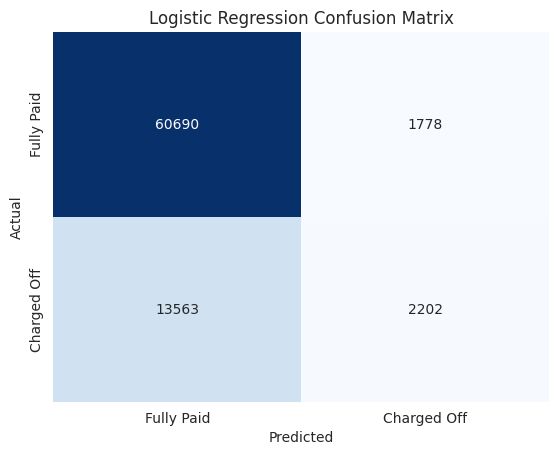

In [61]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",cbar=False,xticklabels=["Fully Paid","Charged Off"],yticklabels=["Fully Paid","Charged Off"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

###Aplicando Logistic Regression balanced

In [62]:
lr_balanced=LogisticRegression(max_iter=1000, random_state=42,class_weight="balanced")
lr_balanced.fit(X_train,y_train)
y_pred_balanced=lr_balanced.predict(X_test)
y_pred_proba_balanced=lr_balanced.predict_proba(X_test)[:,1]


print("Logistic regresion balanced metrics")
print(f"roc auc: {roc_auc_score(y_test,y_pred_proba_balanced):.4f}")
print(f"\n{classification_report(y_test,y_pred_balanced,target_names=["Fully Paid","Charged Off"])}")


Logistic regresion balanced metrics
roc auc: 0.7286

              precision    recall  f1-score   support

  Fully Paid       0.88      0.70      0.78     62468
 Charged Off       0.35      0.63      0.45     15765

    accuracy                           0.68     78233
   macro avg       0.61      0.67      0.61     78233
weighted avg       0.77      0.68      0.71     78233



### Random Forest

In [63]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf=rf.predict(X_test)
y_pred_proba_rf=rf.predict_proba(X_test)[:,1]

In [64]:
print("Random Forest Metrics")
print(f"Roc Auc: {roc_auc_score(y_test,y_pred_proba_rf):.4f}")
print(f"\n{classification_report(y_test,y_pred_rf,target_names=['Fully Paid','Charged Off'])}")

Random Forest Metrics
Roc Auc: 0.7309

              precision    recall  f1-score   support

  Fully Paid       0.89      0.67      0.76     62468
 Charged Off       0.34      0.67      0.45     15765

    accuracy                           0.67     78233
   macro avg       0.61      0.67      0.61     78233
weighted avg       0.78      0.67      0.70     78233



###Xboost

In [65]:
from xgboost import XGBClassifier
#Ratio of unbalancing
scale=(y_train==0).sum()/(y_train==1).sum()

In [66]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=10,
    learning_rate=0.05,
    scale_pos_weight=scale,
    eval_metric="auc",
    random_state=42,
    n_jobs=-1)
xgb.fit(X_train, y_train)

y_pred_xgb=xgb.predict(X_test)
y_pred_proba_xgb=xgb.predict_proba(X_test)[:,1]

In [67]:
print("XGBoost Metrics")
print(f"ROC AUC:{roc_auc_score(y_test,y_pred_proba_xgb):.4f}")
print(f"\n{classification_report(y_test,y_pred_xgb,target_names=['Fully Paid','Charged Off'])}")

XGBoost Metrics
ROC AUC:0.7256

              precision    recall  f1-score   support

  Fully Paid       0.88      0.72      0.79     62468
 Charged Off       0.35      0.60      0.44     15765

    accuracy                           0.70     78233
   macro avg       0.61      0.66      0.62     78233
weighted avg       0.77      0.70      0.72     78233



### LigthGBM

In [68]:
from lightgbm import LGBMClassifier
lgbm = LGBMClassifier(
    n_estimators=300,
    max_depth=10,
    learning_rate=0.05,
    is_unbalance=True,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgbm.fit(X_train, y_train)
y_pred_lgbm=lgbm.predict(X_test)
y_pred_proba_lgbm=lgbm.predict_proba(X_test)[:,1]



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [69]:
print("LGBM metrics")
print(f"ROC_AUC:{roc_auc_score(y_test,y_pred_proba_lgbm):.4f}")
print(f"\n{classification_report(y_test,y_pred_lgbm,target_names=['Fully Paid','Charged Off'])}")

LGBM metrics
ROC_AUC:0.7346

              precision    recall  f1-score   support

  Fully Paid       0.89      0.66      0.76     62468
 Charged Off       0.34      0.67      0.45     15765

    accuracy                           0.67     78233
   macro avg       0.61      0.67      0.61     78233
weighted avg       0.78      0.67      0.70     78233



No se pudo mejorar el roc_auc asi que procederemos a exportar el mejor modelo en este caso el lightGBM

In [70]:
import joblib
import json
joblib.dump(lgbm,"modelo_credit_scoring.pkl")
joblib.dump(scaler,"scaler_credit_scoring.pkl")
feature_names = X.columns.tolist()
with open("feature_names.json","w") as f:
  json.dump(feature_names,f)
print("Saved")

Saved
